# Meep Setup

First make a data directory and a dummy python code
```
!mkdir h5_files_demo
!touch run_demo.py
```
- Need to see if mpi can be done in colab....
- !mpiexec --help

In [48]:
!nproc # mpi not be worth it, only 2 cores in usual runtime

2


In [14]:
!mkdir h5_files_demo

In [18]:
!pip install -q condacolab
import condacolab
condacolab.install() # expect a kernel restart

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/23.11.0-0/Mambaforge-23.11.0-0-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:14
🔁 Restarting kernel...


In [ ]:
!conda install -c conda-forge pymeep pymeep-extras

Channels:
 - conda-forge
Platform: linux-64
Solving environment: - \ | / - \ | done


==> WARNING: A newer version of conda exists. <==
    current version: 23.11.0
    latest version: 24.9.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - pymeep
    - pymeep-extras


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    aom-3.7.1                  |       h59595ed_0         2.6 MB  conda-forge
    autograd-1.7.0             |     pyhd8ed1ab_0          46 KB  conda-forge
    brotli-1.1.0               |       hd590300_1          19 KB  conda-forge
    brotli-bin-1.1.0           |       hd590300_1          19 KB  conda-forge
    ca-certificates-2024.8.30  |       hbcca054_0         155 KB  conda-forge
    cached-property-1.5.2      |       hd8ed1ab_1           

# Execute meep code

In [ ]:
# # Execute meep code
# exec(open('run_demo.py').read())

In [ ]:
# OR Run code from within notebook
'''
Simple Demo of a source in a box.

1. `source_wavelength` is indeed equal to the value that we enter (in microns)
2. Speed of light here really is ~7um/7sec = 1 (um/sec)
3. `resolution=10` is good (`resolution=5` seems adequate while still being fast)
'''

import meep as mp
import numpy as np

# Simulation parameters
# resolution = 10 # pixels per micron
resolution = 5 # pixels per micron

sx, sy, sz = 40,5,5


# Define materials
air = mp.Medium(epsilon=1)
geometry = [
    mp.Block( # slab of air
        size=mp.Vector3(sx,sy,sz),
        center=mp.Vector3(0, 0, 0),
        material=air),
    ]

# Boundary conditions
PML_THICKNESS = 5
pml_layers = [mp.PML(thickness=PML_THICKNESS)]  # PML absorbing layers
# pml_layers = [mp.Absorber(thickness=PML_THICKNESS)]  # can also use 'absorber' instead of PML
sx += 2*PML_THICKNESS
sy += 2*PML_THICKNESS
sz += 2*PML_THICKNESS
cell = mp.Vector3(sx, sy, sz)  # 3D simulation, z>0

# Sources
_source_wavelength = 7
_source_freq = 1/_source_wavelength
# # Source (continuous wave - CW source)
# sources = [
#     mp.Source(
#                 mp.ContinuousSource(frequency=_source_freq),
#                 component=mp.Ez,
#                 # center=mp.Vector3(0, 0, -geom__ms_sub/2),
#                 # center=mp.Vector3(-geom__ms_length/2, 0, -geom__ms_sub/2),
#                 center=mp.Vector3(0, 0, 0),
#                 size=mp.Vector3(1,1,1)
#         )
# ]

# Gaussian pulse source
sources = [
    mp.Source(
        mp.GaussianSource(
            _source_freq,
            # fwidth = 0.1*_source_freq,
            width = 5, # spatial width of pulse. NOTE: Should be longer than a few wavelengths for a prperly modulated Gaussian wavepacket!
            cutoff=2, # shut down the source after 2 temporal widths
        ),
        component = mp.Ez,
        center=mp.Vector3(0, 0, 0),
        size=mp.Vector3(1,1,1)
    )
]

# Simulation object
sim = mp.Simulation(cell_size=cell,
                    boundary_layers=pml_layers,
                    geometry=geometry,
                    sources=sources,
                    # symmetries=[mp.Mirror(direction=mp.Y)], # Use with caution, this can forbid some modes from being launched!
                    resolution=resolution,
                    # eps_averaging=False
                    )

# Run the simulation for a certain number of timesteps
# sim.run(until=50)
# --------------------------------------------------
# Initialize the simulation and output the epsilon (dielectric constant) map
sim.init_sim()

# Dummy run to output the epsilon file
sim.run(
    mp.at_beginning(mp.output_epsilon),
    # until=0) # just for geometry export
    mp.at_every(1,mp.output_efield_x),
    mp.at_every(1,mp.output_efield_y),
    mp.at_every(1,mp.output_efield_z),
    # mp.at_every(1,mp.output_hfield_x),
    # mp.at_every(1,mp.output_hfield_y),
    # mp.at_every(1,mp.output_hfield_z),
    until=40)
    # until=10)

import os
# os.system("h5tovtk *.h5")
os.system("mv *.h5 h5_files_demo")
print("Done! ====================")

In [16]:
# In case of partial run, move data manually into data folder
# ! mv *.h5 h5_files_demo

# Post Processing

In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [5]:
def fetchVectorData(file_template, field='e'):
    # field can be either 'e','h', or 's' (Poynting vector)
    data = {} # dict for x,y,z arrays
    for c in ['x','y','z']:
        filename = file_template.format(field,c)
        # print(f'Reading {filename} ...')
        f = h5py.File(filename)
        data[f'{field}{c}'] = np.array(f[f'{field}{c}'])

    u = data[f'{field}x']
    v = data[f'{field}y']
    w = data[f'{field}z']
    return u,v,w



def readDataset(dir,start,stop, prefix="colab_kernel_launcher"):
  # "colab_kernel_launcher" is from the condacolab setup we have here
    data_series = []

    # for t in range(10,24):
    for t in range(start,stop+1):
        if t<10:
            t = '0'+str(t)
        file_template = dir + "/" + prefix + "-{}{}-0000__TIME__.00.h5"
        file_template = file_template.replace("__TIME__",str(t)) # crude jugaad, but works
        # print(file_template)
        u,v,w = fetchVectorData(file_template,field='e')

        # we want mp.Ez, which is 'w' here
        # Cut along middle of y index range
        _mid = int(w.shape[1]/2)
        data_series.append(w[:,_mid,:])  # new geometry is smaller

    return data_series

# Exporting some animations


Loading data

In [6]:
# NOTE: Can cause kernel crash
data_series = readDataset("./h5_files_demo",start=1,stop=40,prefix="colab_kernel_launcher")
# data_series = readDataset(".",1,20, prefix="run_demo") # use for partial runs

Export a 1D GIF of the field

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Parameters
# slice_row = 75  # Row to slice for the 1D visualization
slice_row = int(data_series[0].shape[1]/2)  # Row to slice for the 1D visualization
frames_1d = []

for i, data in enumerate(data_series):
    # Create a figure for the 1D slice
    fig, ax = plt.subplots(figsize=(6, 4))
    # ax.plot(data[:, slice_row], color='blue', marker='o', label=f"Frame {i+1}")
    ax.plot(data[:, slice_row], color='blue', label=f"Frame {i+1}")
    ax.set_title(f"1D Slice - Row {slice_row}")
    ax.set_xlabel("Index")
    ax.set_ylabel("Value")
    _lim = 30e-3
    ax.set_ylim(-_lim, _lim)  # Adjust based on the data range
    ax.legend()
    ax.grid(True)

    # Save the figure to a buffer
    fig.canvas.draw()
    image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
    image = image.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    frames_1d.append(Image.fromarray(image))

    plt.close(fig)

# Save the 1D slice GIF
frames_1d[0].save(
    'h5_files_demo/fields_1D.gif',
    save_all=True,
    append_images=frames_1d[1:],
    duration=100,  # Duration in milliseconds between frames
    loop=0  # 0 for infinite loop
)

print("GIF saved as 'h5_files_demo/fields_1D.gif'.")


<ipython-input-49-4f310de42175>:25: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed two minor releases later. Use buffer_rgba instead.
  image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')


GIF saved as 'h5_files_demo/fields_1D.gif'.


Export a 2D GIF of the field

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Determine the global min and max for the entire series
global_vmin = np.min([np.min(data) for data in data_series])
global_vmax = np.max([np.max(data) for data in data_series])

# Create a list to store the frames
frames_2d = []

for i, data in enumerate(data_series):
    # Create a figure and plot
    fig, ax = plt.subplots()
    im = ax.imshow(data, cmap='viridis', vmin=global_vmin, vmax=global_vmax)
    plt.axis('off')  # Hide axes for a cleaner image

    # Add frame number annotation
    ax.text(
        0.95, 0.05, f"Frame {i+1}",
        color='white', fontsize=12, ha='right', va='bottom',
        transform=ax.transAxes, backgroundcolor='black'
    )

    # Save the figure to a buffer
    fig.canvas.draw()
    image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
    image = image.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    frames_2d.append(Image.fromarray(image))

    plt.close(fig)

# Save the 2D-only GIF
frames_2d[0].save(
    'h5_files_demo/fields_2D.gif',
    save_all=True,
    append_images=frames_2d[1:],
    duration=100,  # Duration in milliseconds between frames
    loop=0  # 0 for infinite loop
)

print("GIF saved as 'h5_files_demo/fields_2D.gif'.")


<ipython-input-50-676613db3d03>:27: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed two minor releases later. Use buffer_rgba instead.
  image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')


GIF saved as 'h5_files_demo/fields_2D.gif'.


# Plot just a snapshot

Text(0, 0.5, 'Amplitude')

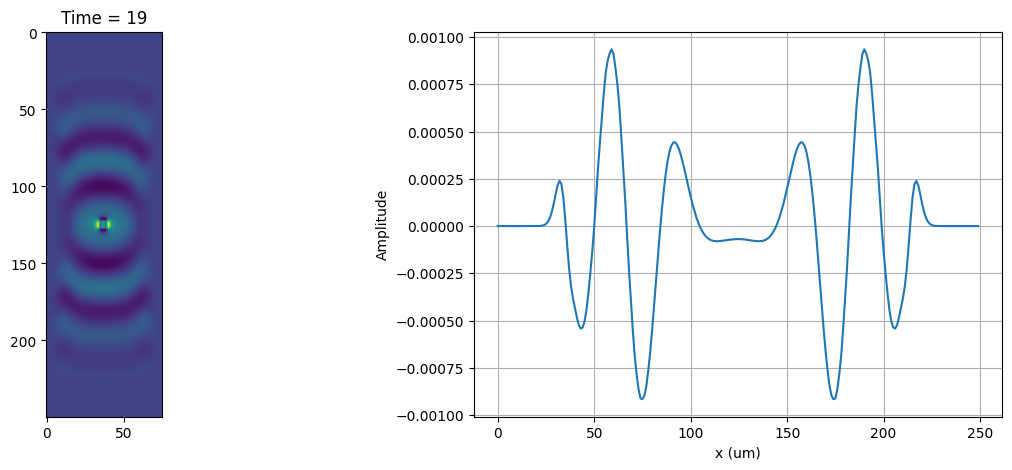

In [8]:
# Plot just a snapshot
k = 19 # time instant in seconds

fig, axes = plt.subplots(1,2,figsize=(15,5))
axes[0].imshow(data_series[k])
axes[0].set_title(f'Time = {k}')
axes[1].plot(data_series[k][:,70])
axes[1].grid()#(data_series[k][:,70])
axes[1].set_xlabel("x (um)")
axes[1].set_ylabel("Amplitude")
# axes[1].title(f'Slice along y=0, time = {k}')

In [ ]:


# Visualizaing with mayavi has issues (https://stackoverflow.com/questions/77674696/mayavi-crashing-in-colab-jupyter-notebook)
# # !pip install mayavi
# # !pip install configobj
# # !pip install PyQt5
# from mayavi import mlab
# # mlab.init_notebook()
# # mlab.options.offscreen = True
# # s = mlab.test_plot3d()

In [ ]:
# file_template = "./h5_files_demo/colab_kernel_launcher-{}{}-000020.00.h5"
# u,v,w = fetchVectorData(file_template,field='e')
# src = mlab.pipeline.vector_field(u, v, w)

# s = mlab.pipeline.vector_cut_plane(src, mask_points=1, scale_factor=10)
# # mlab.outline()
# mlab.colorbar()
